<a href="https://colab.research.google.com/github/PhParsa/PhParsa/blob/main/stack_overflow_bag_of_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses


In [120]:
print(tf.__version__)

2.20.0


In [121]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

dataset = tf.keras.utils.get_file("stack_overflow_16k.tar", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

dataset_dir = os.path.join(dataset)

In [122]:
dataset_dir

'./stack_overflow_16k_extracted'

In [123]:
os.listdir(dataset_dir)

['README.md', 'test', 'train']

In [124]:
train_dir = os.path.join(dataset_dir, 'train')
os.listdir(train_dir)

['javascript', 'python', 'java', 'csharp']

In [125]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


In [126]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only uses the default constru

In [127]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])
print("Label 2 corresponds to", raw_train_ds.class_names[2])
print("Label 3 corresponds to", raw_train_ds.class_names[3])

Label 0 corresponds to csharp
Label 1 corresponds to java
Label 2 corresponds to javascript
Label 3 corresponds to python


In [128]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


In [129]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/test',
    batch_size=batch_size)

Found 8000 files belonging to 4 classes.


# **WITH STANDARDIZATION**

In [62]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<br />', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

In [130]:
max_features = 100000
sequence_length = 2500

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [131]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [132]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [133]:
vectorize_layer([ "it is AMAZING. wow" ])

<tf.Tensor: shape=(1, 2500), dtype=int64, numpy=array([[  11,    6, 6910, ...,    0,    0,    0]])>

In [134]:
vectorize_layer.get_vocabulary()[10]

np.str_('if')

In [135]:
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'"unit testing of setters and getters teacher wanted us to do a comprehensive unit test. for me, this will be the first time that i use junit. i am confused about testing set and get methods. do you think should i test them? if the answer is yes; is this code enough for testing?..  public void testsetandget(){.    int a = 10;.    class firstclass = new class();.    firstclass.setvalue(10);.    int value = firstclass.getvalue();.    assert.asserttrue(""error"", value==a);.  }...in my code, i think if there is an error, we can\'t know that the error is deriving because of setter or getter."\n', shape=(), dtype=string)
Label java
Vectorized review (<tf.Tensor: shape=(1, 2500), dtype=int64, numpy=array([[1011,  773,    9, ...,    0,    0,    0]])>, <tf.Tensor: shape=(), dtype=int32, numpy=1>)


In [136]:
print("1287 ---> ",vectorize_layer.get_vocabulary()[1287])
print(" 313 ---> ",vectorize_layer.get_vocabulary()[313])
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

1287 --->  scissors
 313 --->  source
Vocabulary size: 99853


In [137]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [138]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [139]:
embedding_dim = 16

In [140]:
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(4)])

model.summary()

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['sparse_categorical_accuracy'])

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [103]:
#WITH STANDARDIZATION
epochs = 100
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9335 - sparse_categorical_accuracy: 0.6253 - val_loss: 1.0067 - val_sparse_categorical_accuracy: 0.5788
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9139 - sparse_categorical_accuracy: 0.6428 - val_loss: 0.9701 - val_sparse_categorical_accuracy: 0.6131
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9109 - sparse_categorical_accuracy: 0.6380 - val_loss: 0.9834 - val_sparse_categorical_accuracy: 0.6012
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9058 - sparse_categorical_accuracy: 0.6380 - val_loss: 0.9652 - val_sparse_categorical_accuracy: 0.6106
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8889 - sparse_categorical_accuracy: 0.6459 - val_loss: 0.9156 - val_sparse_categorical_accuracy: 0.6531
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8764 - sparse_categorical_accuracy: 0.6548 - val_loss: 0.9495 - val_sparse_categorical_accuracy: 0.616

In [104]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6184 - sparse_categorical_accuracy: 0.7642
Loss:  0.6184441447257996
Accuracy:  0.7642499804496765


In [105]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

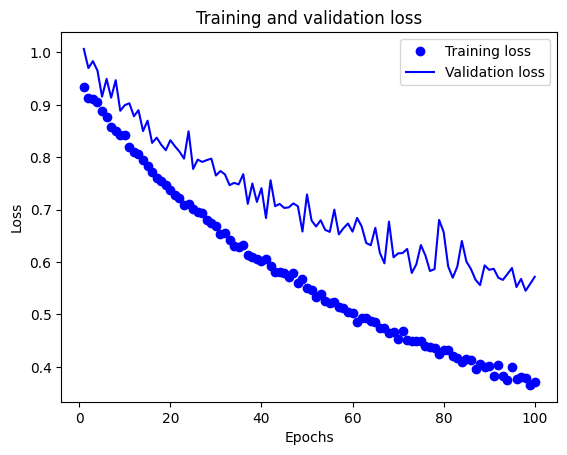

In [107]:
acc = history_dict['sparse_categorical_accuracy']
val_acc = history_dict['val_sparse_categorical_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

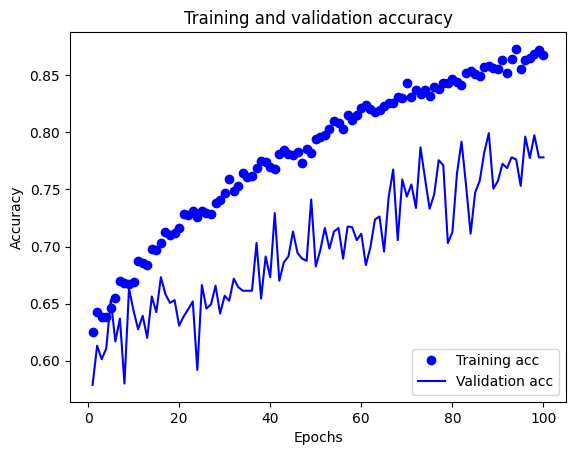

In [108]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [115]:
model.compile(loss=losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.optimizers.Adam(learning_rate=0.0001),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2940 - sparse_categorical_accuracy: 0.9230 - val_loss: 0.5276 - val_sparse_categorical_accuracy: 0.8062
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2957 - sparse_categorical_accuracy: 0.9223 - val_loss: 0.5247 - val_sparse_categorical_accuracy: 0.8050
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2914 - sparse_categorical_accuracy: 0.9236 - val_loss: 0.5211 - val_sparse_categorical_accuracy: 0.8156
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2934 - sparse_categorical_accuracy: 0.9233 - val_loss: 0.5246 - val_sparse_categorical_accuracy: 0.8075
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2927 - sparse_categorical_accuracy: 0.9230 - val_loss: 0.5211 - val_sparse_categorical_accuracy: 0.8138
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2907 - sparse_categorical_accuracy: 0.9255 - val_loss: 0.5260 - val_sparse_categorical_accuracy: 0.8069
Epoc

In [116]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5694 - sparse_categorical_accuracy: 0.7883
Loss:  0.5693521499633789
Accuracy:  0.7882500290870667


In [118]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('softmax')
])

export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
loss, accuracy = export_model.evaluate(raw_test_ds)
print(accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7883 - loss: 0.5694
0.7882500290870667


# **WITHOUT STANDARDIZATION**

In [142]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

dataset = tf.keras.utils.get_file("stack_overflow_16k.tar", url,
                                    untar=True, cache_dir='.',
                                    cache_subdir='')

dataset_dir = os.path.join(dataset)

In [143]:
batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


In [144]:
for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(3):
    print("Review", text_batch.numpy()[i])
    print("Label", label_batch.numpy()[i])

Review b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only uses the default constru

In [145]:
print("Label 0 corresponds to", raw_train_ds.class_names[0])
print("Label 1 corresponds to", raw_train_ds.class_names[1])
print("Label 2 corresponds to", raw_train_ds.class_names[2])
print("Label 3 corresponds to", raw_train_ds.class_names[3])

Label 0 corresponds to csharp
Label 1 corresponds to java
Label 2 corresponds to javascript
Label 3 corresponds to python


In [146]:
raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


In [147]:
raw_test_ds = tf.keras.utils.text_dataset_from_directory(
    './stack_overflow_16k_extracted/test',
    batch_size=batch_size)

Found 8000 files belonging to 4 classes.


In [148]:
max_features = 100000
sequence_length = 2500

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [149]:
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [150]:
def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

In [151]:
text_batch, label_batch = next(iter(raw_train_ds))
first_review, first_label = text_batch[0], label_batch[0]
print("Review", first_review)
print("Label", raw_train_ds.class_names[first_label])
print("Vectorized review", vectorize_text(first_review, first_label))

Review tf.Tensor(b'"unit testing of setters and getters teacher wanted us to do a comprehensive unit test. for me, this will be the first time that i use junit. i am confused about testing set and get methods. do you think should i test them? if the answer is yes; is this code enough for testing?..  public void testsetandget(){.    int a = 10;.    class firstclass = new class();.    firstclass.setvalue(10);.    int value = firstclass.getvalue();.    assert.asserttrue(""error"", value==a);.  }...in my code, i think if there is an error, we can\'t know that the error is deriving because of setter or getter."\n', shape=(), dtype=string)
Label java
Vectorized review (<tf.Tensor: shape=(1, 2500), dtype=int64, numpy=array([[1011,  773,    9, ...,    0,    0,    0]])>, <tf.Tensor: shape=(), dtype=int32, numpy=1>)


In [152]:
print('Vocabulary size: {}'.format(len(vectorize_layer.get_vocabulary())))

Vocabulary size: 99853


In [153]:
train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

In [154]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [155]:
embedding_dim = 16

In [156]:
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),
  layers.Dropout(0.2),
  layers.GlobalAveragePooling1D(),
  layers.Dropout(0.2),
  layers.Dense(4)])

model.summary()

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['sparse_categorical_accuracy'])

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [157]:
#WITHOUT STANDARDIZATION
epochs = 100
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.3936 - sparse_categorical_accuracy: 0.2575 - val_loss: 1.3843 - val_sparse_categorical_accuracy: 0.2344
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3882 - sparse_categorical_accuracy: 0.2658 - val_loss: 1.3849 - val_sparse_categorical_accuracy: 0.2331
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3838 - sparse_categorical_accuracy: 0.2752 - val_loss: 1.3849 - val_sparse_categorical_accuracy: 0.2431
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3793 - sparse_categorical_accuracy: 0.2842 - val_loss: 1.3824 - val_sparse_categorical_accuracy: 0.2387
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3765 - sparse_categorical_accuracy: 0.2923 - val_loss: 1.3816 - val_sparse_categorical_accuracy: 0.2387
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3723 - sparse_categorical_accuracy: 0.3053 - val_loss: 1.3787 - val_sparse_categorical_accuracy: 0.24

In [158]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7646 - sparse_categorical_accuracy: 0.6833
Loss:  0.7646441459655762
Accuracy:  0.6832500100135803


In [159]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

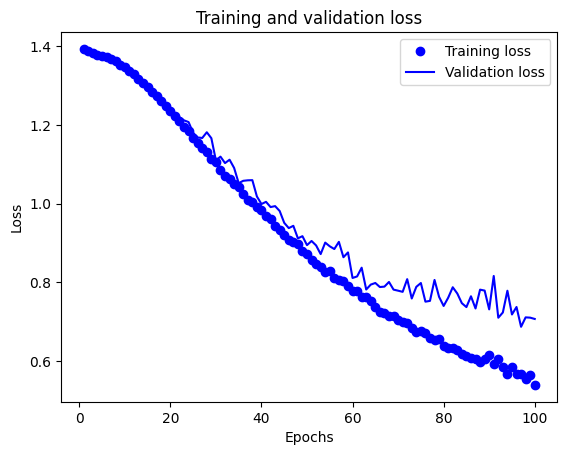

In [160]:
acc = history_dict['sparse_categorical_accuracy']
val_acc = history_dict['val_sparse_categorical_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

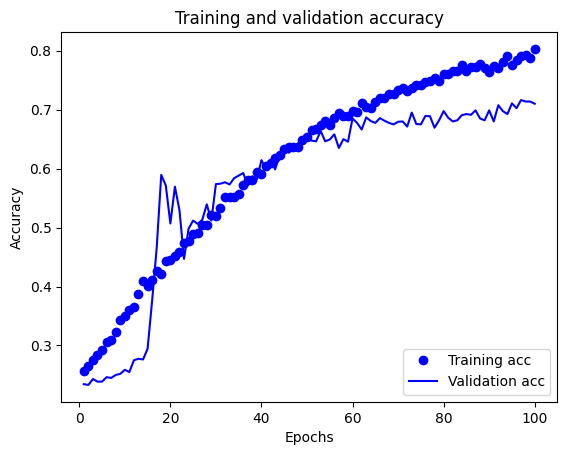

In [161]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [162]:
model.compile(loss=losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.optimizers.Adam(learning_rate=0.0001),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4714 - sparse_categorical_accuracy: 0.8675 - val_loss: 0.6113 - val_sparse_categorical_accuracy: 0.7744
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4727 - sparse_categorical_accuracy: 0.8667 - val_loss: 0.6111 - val_sparse_categorical_accuracy: 0.7750
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4671 - sparse_categorical_accuracy: 0.8692 - val_loss: 0.6092 - val_sparse_categorical_accuracy: 0.7775
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4670 - sparse_categorical_accuracy: 0.8684 - val_loss: 0.6120 - val_sparse_categorical_accuracy: 0.7756
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4653 - sparse_categorical_accuracy: 0.8683 - val_loss: 0.6117 - val_sparse_categorical_accuracy: 0.7744
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4675 - sparse_categorical_accuracy: 0.8670 - val_loss: 0.6093 - val_sparse_categorical_accuracy: 0.7769
Epoc

In [163]:
loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6484 - sparse_categorical_accuracy: 0.7545
Loss:  0.6484113335609436
Accuracy:  0.7544999718666077


In [164]:
export_model = tf.keras.Sequential([
  vectorize_layer,
  model,
  layers.Activation('softmax')
])

export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

# Test it with `raw_test_ds`, which yields raw strings
loss, accuracy = export_model.evaluate(raw_test_ds)
print(accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7545 - loss: 0.6484
0.7544999718666077


# **RNN**

In [171]:
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

tfds.disable_progress_bar()

In [166]:
import string,re

In [178]:
VOCAB_SIZE = 10000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)

encoder.adapt(raw_train_ds.map(lambda text, label: text))

In [194]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4)
])

In [190]:
print([layer.supports_masking for layer in model.layers])

[False, True, True, True, True]


In [195]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [196]:
history = model.fit(raw_train_ds, epochs=30,
                    validation_data=raw_val_ds,
                    validation_steps=90)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.2919 - loss: 1.3845 - val_accuracy: 0.3175 - val_loss: 1.3812
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.4431 - loss: 1.2662 - val_accuracy: 0.4162 - val_loss: 1.2061
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.6386 - loss: 0.9205 - val_accuracy: 0.6000 - val_loss: 0.9307
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7423 - loss: 0.6848 - val_accuracy: 0.7362 - val_loss: 0.6676
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7886 - loss: 0.5773 - val_accuracy: 0.7469 - val_loss: 0.6579
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.8120 - loss: 0.5207 - val_accuracy: 0.5562 - val_loss: 0.9202
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7877 - loss: 0.5978 - val_accuracy: 0.7644 - val_loss: 0.6182
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8694 - loss: 0.3921 - val_acc

In [201]:
test_loss, test_acc = model.evaluate(raw_test_ds)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7458 - loss: 1.2253
Test Loss: 1.2253003120422363
Test Accuracy: 0.7457500100135803


In [204]:
import matplotlib.pyplot as plt


def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

(0.0, 2.56517988499254)

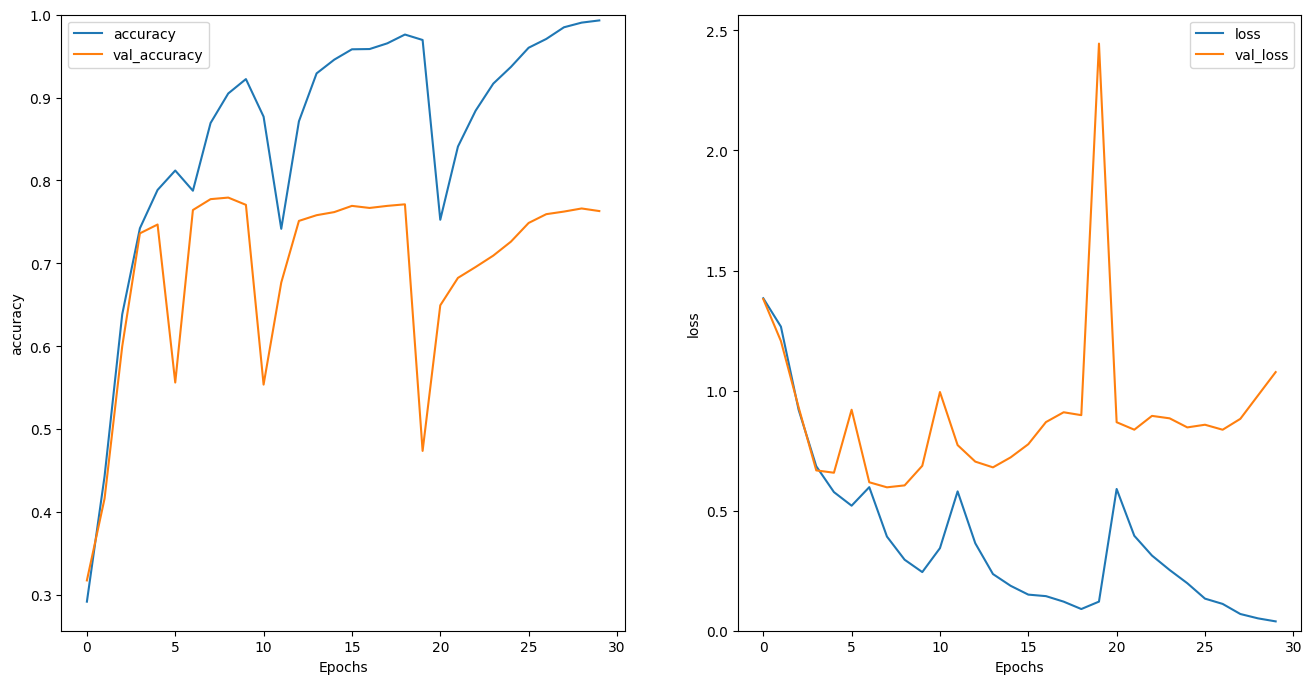

In [205]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

In [207]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4)
])

In [211]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [212]:
history = model.fit(raw_train_ds, epochs=30,
                    validation_data=raw_val_ds,
                    validation_steps=90)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.2781 - loss: 1.3851 - val_accuracy: 0.3231 - val_loss: 1.3826
Epoch 2/30
  3/200 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.3229 - loss: 1.3827 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4253 - loss: 1.2493 - val_accuracy: 0.5850 - val_loss: 1.0245
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.5950 - loss: 0.9357 - val_accuracy: 0.6250 - val_loss: 0.8705
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6719 - loss: 0.7528 - val_accuracy: 0.6469 - val_loss: 0.8505
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.6970 - loss: 0.6717 - val_accuracy: 0.6819 - val_loss: 0.7368
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.7383 - loss: 0.5748 - val_accuracy: 0.6994 - val_loss: 0.7200
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.7728 - loss: 0.5141 - val_accuracy: 0.6944 - val_loss: 0.7590
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8066 - loss: 0.4650 - val_accuracy: 0.7362 - val_loss: 0.7381
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.8477 - loss: 0.3952 - val_accurac

In [213]:
test_loss, test_acc = model.evaluate(raw_test_ds)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7304 - loss: 1.5034
Test Loss: 1.5033763647079468
Test Accuracy: 0.7303749918937683


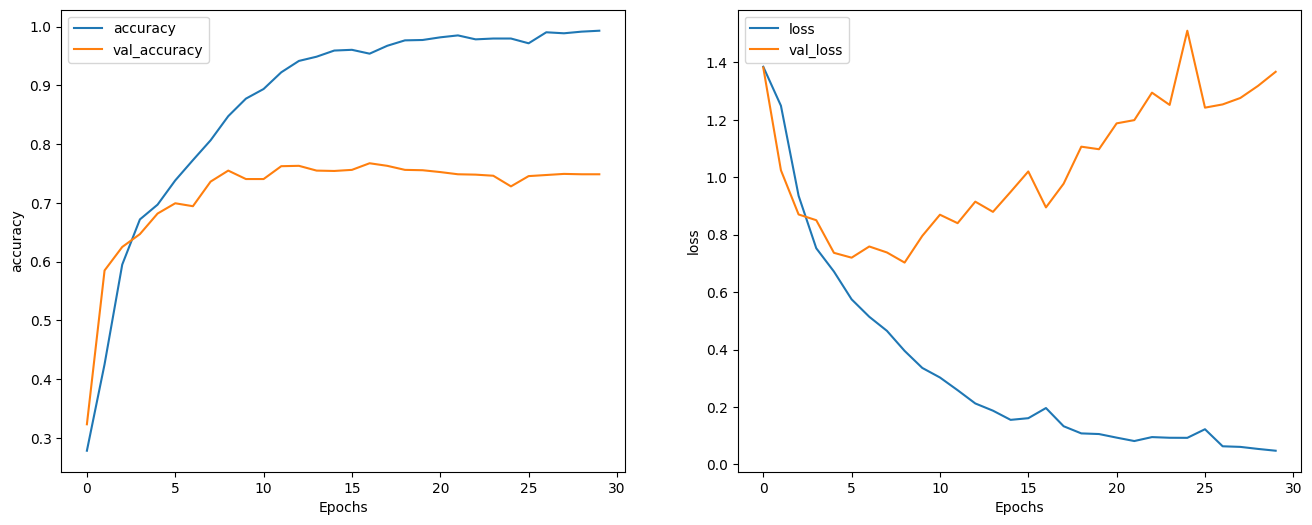

In [214]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')